# Gravity data processing
## Molly Bilhartz, Samantha Lopez, Tessa Murphy

For a mine shaft, you are typically looking for:

A local gravity low (negative anomaly) caused by missing mass (air-filled or partially collapsed void).
An anomaly that is relatively narrow compared to regional trends.
A residual anomaly after removing any remaining long-wavelength trend.


load in corrected data, take out regional trend, and then test negative shaft anomalies to the residual to find geometry. 

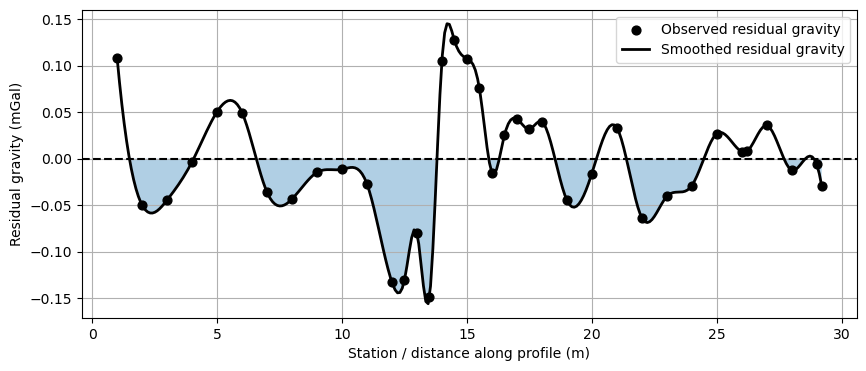

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# -----------------------------
# Load corrected gravity data
# -----------------------------
df = pd.read_csv("../../data/gravity/Onyx_Gravity_Final_Bouguer_Corrected.csv")
df = df.sort_values("station").reset_index(drop=True)

x = df["station"].values.astype(float)
g_obs = df["gravity_final_mgal"].values.astype(float)

std = np.ones_like(g_obs) * 0.02  # assumed uncertainty in mGal

# -----------------------------
# Remove regional trend
# -----------------------------
trend_order = 2

trend_poly = np.polynomial.Polynomial.fit(
    x,
    g_obs,
    deg=trend_order,
    w=1 / std
)

g_trend = trend_poly(x)
g_resid = g_obs - g_trend

df["regional_trend_mgal"] = g_trend
df["residual_mgal"] = g_resid

# plt.figure(figsize=(10,4))
# plt.plot(x, g_obs, "o-", label="Observed Bouguer gravity")
# plt.plot(x, g_trend, "--", label="Regional trend")
# plt.xlabel("Station / distance along profile (m)")
# plt.ylabel("Gravity (mGal)")
# plt.title("Bouguer Gravity and Regional Trend")
# plt.grid(True)
# plt.legend()
# plt.show()

# plt.figure(figsize=(10,4))
# plt.axhline(0, color="k", linestyle="--")
# plt.plot(x, g_resid, "o-", label="Residual gravity", color='black')
# plt.fill_between(x, g_resid, 0, where=g_resid < 0, alpha=0.35)
# plt.xlabel("Station / distance along profile (m)")
# plt.ylabel("Residual gravity (mGal)")
# #plt.title("Residual Gravity Anomaly")
# plt.grid(True)
# plt.legend()
# plt.savefig(
#      "../../figures/Final_figures/Grav_Residual_Anomaly_B4_Elevation_Correction.png",
#     dpi=300,
#     bbox_inches="tight"
# )
# plt.show()
from scipy.interpolate import make_interp_spline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Combine x and residuals, then average duplicate station distances
profile = (
    pd.DataFrame({"x": x, "g_resid": g_resid})
    .dropna()
    .groupby("x", as_index=False)
    .mean()
    .sort_values("x")
)

x_plot = profile["x"].to_numpy()
g_plot = profile["g_resid"].to_numpy()

# Smooth spline
x_smooth = np.linspace(x_plot.min(), x_plot.max(), 300)
spline = make_interp_spline(x_plot, g_plot, k=3)
g_smooth = spline(x_smooth)

plt.figure(figsize=(10,4))
plt.axhline(0, color="k", linestyle="--")

plt.scatter(
    x_plot,
    g_plot,
    color="black",
    s=40,
    label="Observed residual gravity",
    zorder=3
)

plt.plot(
    x_smooth,
    g_smooth,
    color="black",
    linewidth=2,
    label="Smoothed residual gravity"
)

plt.fill_between(
    x_smooth,
    g_smooth,
    0,
    where=g_smooth < 0,
    alpha=0.35
)

plt.xlabel("Station / distance along profile (m)")
plt.ylabel("Residual gravity (mGal)")
plt.grid(True)
plt.legend()

plt.savefig(
    "../../figures/Final_figures/Grav_Residual_Anomaly_B4_Elevation_Correction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# -------------------------------------------------------
# Horizontal tunnel gravity model
# Tunnel is treated as a long horizontal void crossing
# beneath the gravity line with square cross section.
# -------------------------------------------------------

G = 6.67430e-11
FT_TO_M = 0.3048

tunnel_length = 200 * FT_TO_M   # 60.96 m

def finite_horizontal_square_tunnel_gravity(
    x_obs,
    x0,
    side_length,
    depth_center,
    density_contrast_gcc=-2.35,
    length=tunnel_length,
    n_y=400
):
    """
    Gravity anomaly from a finite horizontal tunnel.

    Tunnel axis is assumed perpendicular to the gravity profile.
    The gravity line crosses the tunnel in map view.
    """

    density_contrast = density_contrast_gcc * 1000  # kg/m³
    area = side_length**2                           # m²

    y = np.linspace(-length/2, length/2, n_y)
    dy = y[1] - y[0]

    gz = np.zeros_like(x_obs, dtype=float)

    for yi in y:
        dx = x_obs - x0
        r2 = dx**2 + yi**2 + depth_center**2
        r = np.sqrt(r2)

        dV = area * dy
        dm = density_contrast * dV

        gz += G * dm * depth_center / r**3

    return gz * 1e5  # mGal

In [33]:
# -----------------------------
# Fit tunnel model to residual
# -----------------------------
from scipy.optimize import differential_evolution

def misfit_finite_tunnel(params):
    x0, side_length, depth_center, density_contrast = params

    g_model = finite_horizontal_square_tunnel_gravity(
        x,
        x0=x0,
        side_length=side_length,
        depth_center=depth_center,
        density_contrast_gcc=density_contrast
    )

    return np.mean(((g_model - g_resid) / std)**2)

bounds = [
    (10.0, 16.0),     # tunnel center near gravity low
    (2.0, 3.0),       # tunnel side length, m
    (4.0, 20.0),      # depth to tunnel center, m
    (-2.5, -2.2)      # sandstone-to-air density contrast
]

result = differential_evolution(
    misfit_finite_tunnel,
    bounds,
    seed=42,
    polish=True
)

x0_best, side_best, depth_best, drho_best = result.x

g_best = finite_horizontal_square_tunnel_gravity(
    x,
    x0=x0_best,
    side_length=side_best,
    depth_center=depth_best,
    density_contrast_gcc=drho_best
)

print("Best-fitting finite horizontal tunnel model")
print("------------------------------------------")
print(f"Tunnel length:        {tunnel_length:.5f} m")
print(f"Tunnel length:        {tunnel_length / FT_TO_M:.5f} ft")
print(f"Tunnel center x:      {x0_best:.5f} m")
print(f"Side length:          {side_best:.5f} m")
print(f"Area:                 {side_best**2:.5f} m²")
print(f"Area:                 {side_best**2 / 0.09290304:.5f} ft²")
print(f"Depth to center:      {depth_best:.5f} m")
print(f"Depth to top:         {depth_best - side_best/2:.5f} m")
print(f"Depth to bottom:      {depth_best + side_best/2:.5f} m")
print(f"Density contrast:     {drho_best:.5f} g/cm³")
print(f"Misfit:               {result.fun:.5f}")

Best-fitting finite horizontal tunnel model
------------------------------------------
Tunnel length:        60.96000 m
Tunnel length:        200.00000 ft
Tunnel center x:      10.28863 m
Side length:          2.00000 m
Area:                 4.00000 m²
Area:                 43.05564 ft²
Depth to center:      4.00000 m
Depth to top:         3.00000 m
Depth to bottom:      5.00000 m
Density contrast:     -2.20000 g/cm³
Misfit:               10.49162


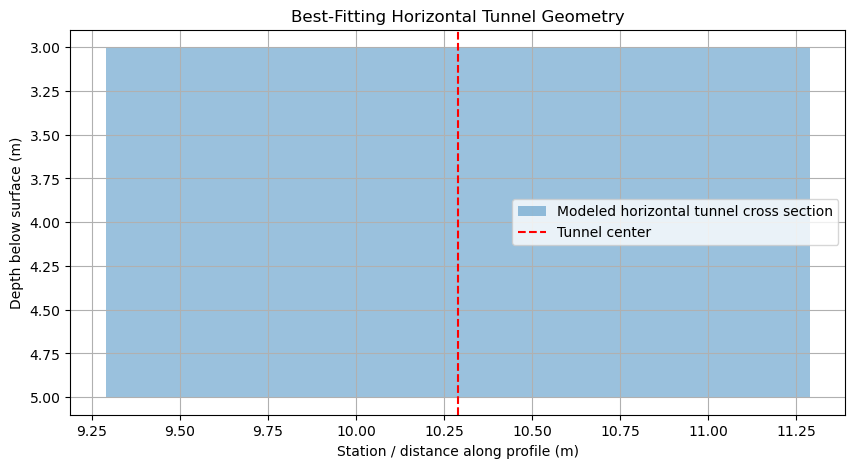

In [37]:
# -----------------------------
# Plot interpreted tunnel geometry
# -----------------------------

left = x0_best - side_best / 2
right = x0_best + side_best / 2
top = depth_best - side_best / 2
bottom = depth_best + side_best / 2

plt.figure(figsize=(10,5))

plt.fill_between(
    [left, right],
    top,
    bottom,
    alpha=0.45,
    label="Modeled horizontal tunnel cross section"
)

plt.axvline(x0_best, color="r", linestyle="--", label="Tunnel center")

plt.gca().invert_yaxis()
plt.xlabel("Station / distance along profile (m)")
plt.ylabel("Depth below surface (m)")
plt.title("Best-Fitting Horizontal Tunnel Geometry")
plt.grid(True)
plt.legend()
plt.show()

# computes the expected anomaly amplitudes for reasonable tunnel cases:

In [42]:
test_cases = []

for side in [2.0, 2.5, 3.0]:
    for depth in [4, 6, 8, 10, 15, 20]:
        g_test = finite_horizontal_square_tunnel_gravity(
            x,
            x0=13.0,
            side_length=side,
            depth_center=depth,
            density_contrast_gcc=-2.5
        )

        test_cases.append({
            "side_m": side,
            "depth_m": depth,
            "min_anomaly_mgal": np.min(g_test),
            "peak_to_peak_mgal": np.max(g_test) - np.min(g_test)
        })

test_df = pd.DataFrame(test_cases)
test_df

,side_m,depth_m,min_anomaly_mgal,peak_to_peak_mgal
0,2.0,4,-0.033089,0.031406
1,2.0,6,-0.021831,0.019495
2,2.0,8,-0.016142,0.013326
3,2.0,10,-0.012687,0.009561
4,2.0,15,-0.007988,0.004659
5,2.0,20,-0.005584,0.002502
6,2.5,4,-0.051702,0.049072
7,2.5,6,-0.034111,0.030460
8,2.5,8,-0.025221,0.020822
9,2.5,10,-0.019823,0.014938


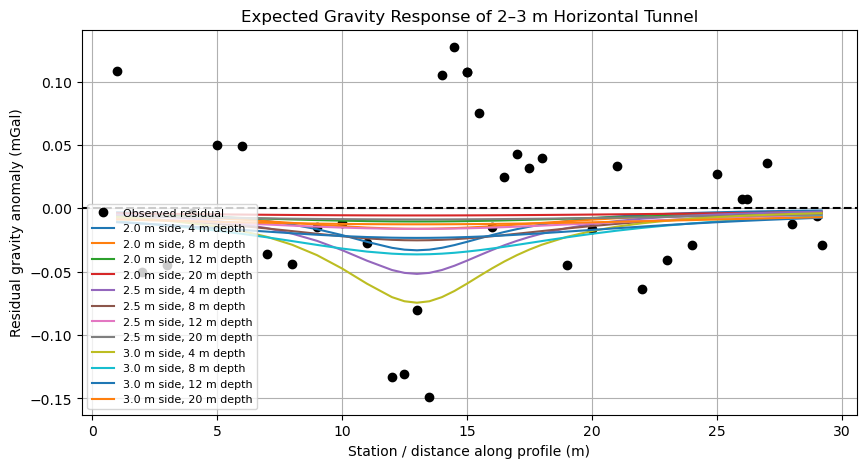

In [44]:
plt.figure(figsize=(10,5))

plt.axhline(0, color="k", linestyle="--")
plt.plot(x, g_resid, "ko", label="Observed residual")

for side in [2.0, 2.5, 3.0]:
    for depth in [4, 8, 12, 20]:
        g_test = finite_horizontal_square_tunnel_gravity(
            x,
            x0=13.0,
            side_length=side,
            depth_center=depth,
            density_contrast_gcc=-2.5
        )

        plt.plot(
            x,
            g_test,
            label=f"{side} m side, {depth} m depth"
        )

plt.xlabel("Station / distance along profile (m)")
plt.ylabel("Residual gravity anomaly (mGal)")
plt.title("Expected Gravity Response of 2–3 m Horizontal Tunnel")
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

The observed residual gravity dots are much more scattered than the smooth tunnel models. The ideal models show that a clean, open 2–3 m tunnel at 4–20 m depth should produce a smooth, symmetric negative anomaly. Your data instead show a broader, noisier negative zone near about 12–14 m, plus several positive and negative jumps elsewhere. That means the gravity response is probably not from a clean rectangular air void alone.
1800s mine workings: the tunnel is probably not a clean open square void. It may be partly collapsed, filled with rubble, fractured, or surrounded by loosened rock. That would make the anomaly broader and less symmetric than the ideal model.

The gravity low is consistent with a low-density mine-related zone, but the field data are too noisy and geologically complex to uniquely model the tunnel geometry. The forward model provides a physical plausibility check, not a definitive image of the tunnel.